In [3]:
import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()

/tmp/ipykernel_125106/3769378289.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [4]:
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [5]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [6]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [7]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_tool_use",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

print("Vector store ready")

Vector store ready


In [8]:
llm = ChatOpenAI(model="gpt-4o-mini")        # route_question and generate

agent_llm = ChatOpenAI(model="gpt-4o-mini")  # agent node; tools bound later

In [9]:
class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool

In [10]:
class RouteDecision(BaseModel):

    needs_retrieval: bool

In [11]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k: int = 3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages."""
    
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(query)
    
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)
    
    return context, docs

In [13]:
@tool(response_format="content_and_artifact")
def web_search(query: str, max_results: int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned."""
    
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)
    return content, docs

In [14]:
tools = [vector_store_search, web_search]

agent_llm_with_tools = agent_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [15]:
# route_question node — classifies whether the query needs retrieval
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [16]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

# agent node — decides which tool(s) to call based on the query
def agent(state: AgenticRAGState) -> dict:

    messages = state["messages"]
    if not messages:
        messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT),
                    HumanMessage(content=state["query"])]

    response = agent_llm_with_tools.invoke(messages)

    return {"messages": [response]}

In [17]:
# collect_tool_output node — drains ToolMessages into state fields
def collect_tool_output(state: AgenticRAGState) -> dict:

    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    all_docs, context_parts = [], []

    for msg in tool_messages:
        context_parts.append(msg.content)
        all_docs.extend(msg.artifact)

    return {
        "context": "\n\n".join(context_parts),
        "retrieved_docs": all_docs,
    }

In [18]:
# generate node — produces the final answer with or without retrieved context
def generate(state: AgenticRAGState) -> dict:

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [19]:
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

In [20]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "agent")
graph_builder.add_edge("collect_tool_output", "generate")
graph_builder.add_edge("generate", END)

In [21]:
graph = graph_builder.compile()

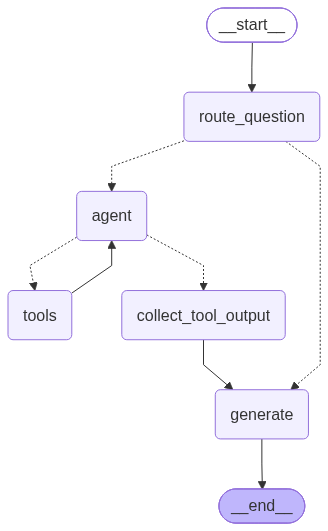

In [22]:
graph

In [23]:
# Case 1: vector store only — domain-specific question about the PDF
query_vs = "According to the report, how will the adoption of electric vehicles impact oil demand?"

result_vs = graph.invoke({"query": query_vs, "messages": [], "retrieved_docs": [], "context": ""})

In [24]:
print("=== CASE 1: Vector Store Only ===")
print(f"needs_retrieval : {result_vs['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_vs.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_vs.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_vs['generation']}")

=== CASE 1: Vector Store Only ===
needs_retrieval : True
retrieved_docs  : 6 docs
context preview : 

## Vector Store Results

Once that parity threshold is crossed, adoption dynamics are expected to shift from
policy-dr...

Generation:
The adoption of electric vehicles (EVs) is expected to impact oil demand by reducing the total quantity of oil consumed. As more internal combustion engine (ICE) vehicles are replaced by EVs on the road, there will be fewer barrels of gasoline and diesel consumed, leading to a decrease in overall oil demand. Additionally, as EV adoption increases, this demand destruction could accelerate, potentially leading to a peak in oil demand arriving earlier than current projections assume. The International Energy Agency (IEA) estimates that oil displacement by EVs could increase significantly over the coming years, reflecting the expected growth in EV sales and adoption.


In [25]:
print(result_vs["context"])



## Vector Store Results

Once that parity threshold is crossed, adoption dynamics are expected to shift from
policy-driven to market-driven, potentially accelerating the pace of displacement beyond what
current policy-based models project. The timing of this transition — and whether cost
reductions continue at historical rates or plateau due to raw material bottlenecks — is the
pivotal uncertainty in long-run oil demand forecasting.
5. Macroeconomic Channels: How EV Penetration
Reshapes Oil Markets
 The relationship between EV adoption and oil price dynamics operates through several
macroeconomic channels that extend well beyond simple demand arithmetic. The most direct
channel is demand destruction: fewer ICE vehicles on the road means fewer barrels of
gasoline and diesel consumed, reducing the total quantity of oil demanded at any given price.

solid-state batteries achieve commercial viability on their announced timelines, the adoption
curves used in current oil demand scenarios m

In [26]:
# Case 2: web search only — current information not in the PDF
query_web = "What is the current temperature in New Delhi?"

result_web = graph.invoke({"query": query_web, "messages": [], "retrieved_docs": [], "context": ""})

In [27]:
print("=== CASE 2: Web Search Only ===")
print(f"needs_retrieval : {result_web['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_web.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_web.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_web['generation']}")

=== CASE 2: Web Search Only ===
needs_retrieval : True
retrieved_docs  : 3 docs
context preview : 

## Web Search Results

1. What is the current temperature in New Delhi today - 19 August 2026?

The current temperatur...

Generation:
The current temperature in New Delhi is 32°C.


In [28]:
# Case 3: both tools — requires document context AND current web data
query_both = "Compare what the EV report projects for 2030 oil demand and also tell me about the weather in mumbai"

result_both = graph.invoke({"query": query_both, "messages": [], "retrieved_docs": [], "context": ""})

In [29]:
print("=== CASE 3: Both Tools ===")
print(f"needs_retrieval : {result_both['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_both.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_both.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_both['generation']}")

=== CASE 3: Both Tools ===
needs_retrieval : True
retrieved_docs  : 6 docs
context preview : 

## Vector Store Results

— a meaningful but not transformative reduction against a global demand base of 100 to 105
mi...

Generation:
The EV report projects that under the IEA's Announced Pledges Scenario, oil demand is expected to peak before 2030, with a decline becoming evident in the 2030s as electric vehicle (EV) fleets grow. In contrast, under OPEC's central scenario, EVs are only expected to displace 2 to 3 million barrels per day by 2030, and oil demand does not peak until the late 2030s. This creates a gap of roughly 5 to 7 million barrels per day between the IEA and OPEC projections, reflecting uncertainty in technology adoption and consumer behavior.

As for the weather in Mumbai, on August 20, 2026, the conditions are characterized by patchy rain nearby, with a temperature of 28°C (feels like 32°C) and humidity around 79%. The wind speed is approximately 19.9 km/h from the west-s

In [30]:
print(result_both["context"])



## Vector Store Results

— a meaningful but not transformative reduction against a global demand base of 100 to 105
million barrels per day. In the 2035–2040 period, displacement could reach 10 to 15 million
barrels per day, sufficient to bring absolute oil demand into structural decline. The IEA's
Announced Pledges Scenario places oil demand peaking before 2030 under current policy
commitments, with the decline accelerating sharply in the 2030s as EV fleets grow and older
ICE vehicles are retired.
 The more moderate scenarios produced by OPEC's own World Oil Outlook project
considerably lower EV adoption rates, reflecting higher assumed consumer price sensitivity,
slower charging infrastructure buildout, and more cautious assumptions about battery cost
trajectories. Under OPEC's central scenario, EVs displace only 2 to 3 million barrels per day

trajectories. Under OPEC's central scenario, EVs displace only 2 to 3 million barrels per day
by 2030 and oil demand does not peak until th

In [31]:
# Case 4: no retrieval — answerable from general knowledge
query_none = "Explain the difference between kinetic energy and potential energy."

result_none = graph.invoke({"query": query_none, "messages": [], "retrieved_docs": [], "context": ""})

In [32]:
print("=== CASE 4: No Retrieval ===")
print(f"needs_retrieval : {result_none['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_none.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_none.get('context', '') or '(none)'}")
print(f"\nGeneration:\n{result_none['generation']}")

=== CASE 4: No Retrieval ===
needs_retrieval : False
retrieved_docs  : 0 docs
context preview : (none)

Generation:
Kinetic energy and potential energy are two fundamental forms of energy in physics that describe the state of an object in relation to motion and position.

1. **Kinetic Energy**:
   - Kinetic energy is the energy an object possesses due to its motion. It depends on the mass of the object and its velocity.
   - The formula for kinetic energy (KE) is given by:
     \[
     KE = \frac{1}{2} mv^2
     \]
     where \( m \) is the mass of the object and \( v \) is its velocity.
   - Examples of kinetic energy include a moving car, a flying baseball, or a running person. The greater the mass and speed of an object, the more kinetic energy it has.

2. **Potential Energy**:
   - Potential energy is the stored energy an object possesses due to its position or configuration. It is often associated with the gravitational force, but can also arise from other forces (like elastic pot

In [33]:
result_both["messages"][0].tool_calls

[{'name': 'vector_store_search',
  'args': {'query': '2030 oil demand projections'},
  'id': 'call_8xU92pmPdQ7qyz9vs2b6n1yb',
  'type': 'tool_call'},
 {'name': 'web_search',
  'args': {'query': 'Mumbai weather forecast'},
  'id': 'call_pTD3FJESCf7frqyqwZpx3Sl4',
  'type': 'tool_call'}]